In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


energy = pd.read_csv("energy_dataset.csv")
print(energy.info())

weather = pd.read_csv("weather_features.csv")
print(weather.info())

energy["time"] = pd.to_datetime(energy["time"] , utc = True)
weather["dt_iso"] = pd.to_datetime(weather["dt_iso"] , utc = True)
#تبدیل ستون های زمانی به فرمت datetime

weather_avg = weather.groupby("dt_iso").mean(numeric_only = True).reset_index()
#میانگین ویژگی های هواشناسی برای هر ساعت چون چندتا شهر مختلفه

data = pd.merge(energy , weather_avg , left_on = "time" , right_on = "dt_iso" , how ="inner" )
#ترکیب دیتاست انرژی و هواشناسی 

print(data.info())

data["hour"] = data["time"].dt.hour
data["dayofweek"] = data["time"].dt.dayofweek
data["month"] = data["time"].dt.month
data["isweekend"] = data["dayofweek"].apply(lambda x : 1 if x >= 5 else 0)
data["lag1"] = data["total load actual"].shift(1)
data["lag24"] = data["total load actual"].shift(24)
#ساخت ویژگی های زمانی

del data["generation hydro pumped storage aggregated"]
del data["forecast wind offshore eday ahead"]

data = data.dropna()
data["temp"] = data["temp"] - 273.15 #تبدیل دما از کلوین به درجه 



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In [23]:
x = data[["hour" , "isweekend" , "month" , "lag1" , "lag24" , "temp" , "humidity" , "wind_speed"]]
y = data["total load actual"]


In [24]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)
#تقسیم داده ها به train و test

In [25]:
model = LinearRegression()
model.fit(x_train , y_train)
# پیش بینی

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred = model.predict(x_test)
#پیش بینی روی داده های تست



In [27]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
#ارزیابی مدل
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")

Mean Squared Error (MSE): 1643527.7857905456
R² Score: 0.9196146590601783


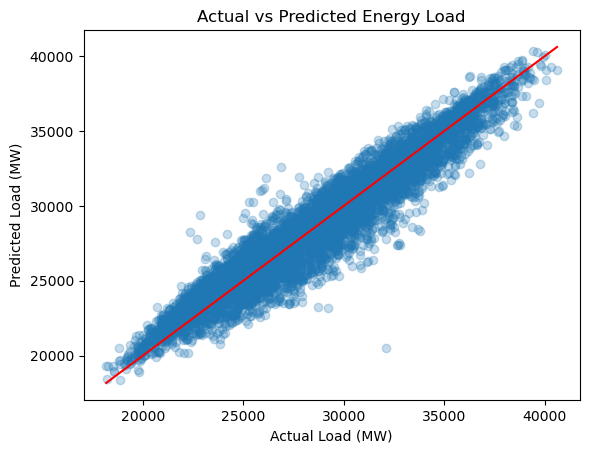

In [28]:
plt.scatter(y_test , y_pred , alpha = 0.25)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , color = "red")
plt.xlabel("Actual Load (MW)")
plt.ylabel('Predicted Load (MW)')
plt.title('Actual vs Predicted Energy Load')
plt.show()

In [ ]:
plt.plot(data["time"] , data['total load actual'] , color = "red")
plt.xlabel("time")
plt.ylabel("total load actual")
plt.xticks(rotation = 45)
plt.title("energy consumption over time")
plt.show()


In [ ]:
plt.scatter(data["month"] , data["total load actual"] , color = "orange" , alpha = 0.25)
plt.xlabel("Month")
plt.ylabel("Total load actual")
plt.title("Energy consumption based on months")
plt.xticks(
    ticks = range(1 , 13),
    labels = ["January", "February", "March", "April", "May", "June", 
            "July", "August", "September", "October", "November", "December"] , rotation = 45)
plt.show()

In [ ]:
plt.scatter(data["hour"] , data["total load actual"] , color = "blue" , alpha = 0.5)
plt.xlabel("hour")
plt.ylabel("total actual load")
plt.title("Energy consumption over hours")
plt.show()

In [ ]:
plt.scatter(data["temp_max"] , data["total load actual"] , color = "purple" , alpha = 0.25 )
plt.show()
plt.scatter(data["temp_min"] , data["total load actual"] , color = "red" , alpha = 0.25 )
plt.show()
            

In [ ]:
plt.plot(data["month"] , data["total load actual"] , color = "teal")
plt.xlabel("month")
plt.ylabel("energy consumption")
plt.title("energy consumption based on months")
plt.show()

In [ ]:
plt.boxplot([data[data["isweekend"] == 0]["total load actual"]
            , data[data["isweekend"] == 1]["total load actual"]],
            tick_labels = ["workday" , "weekend"] )
plt.ylabel("total load actual")
plt.title("energy consumption on workday or weekend")
plt.show()

In [ ]:
plt.scatter(data["humidity"] , data["total load actual"] , color = "green" , alpha = 0.1)
plt.xlabel("Humidity")
plt.ylabel("Total load actual")
plt.title("Energy cinsumption based on humidity")
plt.show()

In [ ]:
plt.scatter(data["wind_speed"] , data["total load actual"] , color = "gray" , alpha = 0.5)
plt.xlabel("Wind speed")
plt.ylabel("Total load actual")
plt.title("Energy consumption based on wind speed")
plt.show()

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
pip install xboost

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
poly = PolynomialFeatures(degree=2)
poly_model = make_pipeline(poly , LinearRegression())
poly_model.fit(x_train , y_train)
y_pred_poly = poly_model.predict(x_test)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Polynomial Regression (Degree 2) MSE: {mse_poly}")
print(f"Polynomial Regression (Degree 2) R²: {r2_poly}")
#مدل رگرسیون چندجمله ای درجه 2

Polynomial Regression (Degree 2) MSE: 1057569.782090113
Polynomial Regression (Degree 2) R²: 0.94895554788923


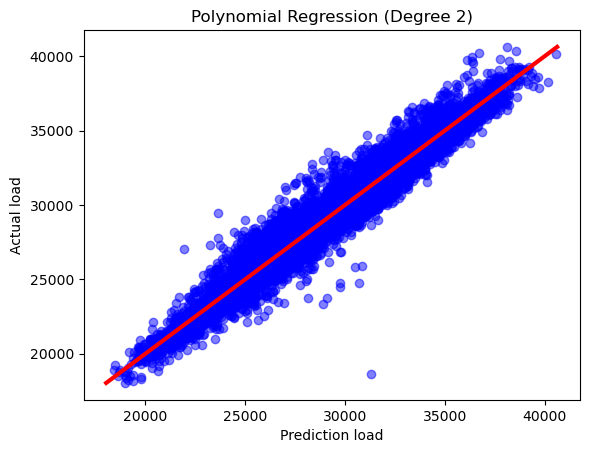

In [45]:
plt.scatter(y_pred_poly , y_test , color = "blue" , alpha = 0.5 )
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , lw = 3 , color = "red")
plt.xlabel("Prediction load")
plt.ylabel("Actual load")
plt.title("Polynomial Regression (Degree 2)")
plt.show()
#نمودار مدل چند جمله ای درجه 2

In [ ]:
poly = PolynomialFeatures(degree=3)
poly_model = make_pipeline(poly , LinearRegression())
poly_model.fit(x_train , y_train)
y_pred_poly = poly_model.predict(x_test)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Polynomial Regression (Degree 3) MSE: {mse_poly}")
print(f"Polynomial Regression (Degree 3) R²: {r2_poly}")
#مدل رگرسیون چندجمله ای درجه 3

In [ ]:
plt.scatter(y_pred_poly , y_test , color = "teal" , alpha = 0.5)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , lw = 3 ,color = "red")
plt.xlabel("Prediction load")
plt.ylabel("Actual load")
plt.title("Polynomial Regression (Degree 3)")
plt.show()
#نمودار مدل چند جمله ای درجه 3

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
model_rf = RandomForestRegressor(n_estimators = 100 , random_state = 42)
model_rf.fit(x_train , y_train)
y_pred_rf = model_rf.predict(x_test)
#آموزش داده ها

In [ ]:
print("Random Forest:")
print(f"MSE: {mean_squared_error(y_test, y_pred_rf)}")
print(f"R²: {r2_score(y_test, y_pred_rf)}")
#نتایجُ

In [ ]:
plt.scatter(y_pred_rf , y_test , alpha = 0.5)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , color = "red" , lw = 2)
plt.xlabel("prediction load")
plt.ylabel("actual load")
plt.title("Randon forest model")
plt.show()

In [ ]:
pip install xgboost

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [30]:
model_xg = XGBRegressor(n_estimators = 100 , random_state = 42)
model_xg.fit(x_train , y_train)
y_pred_xg = model_xg.predict(x_test)

print("Xgboost:")
print(f"MSE: {mean_squared_error(y_test, y_pred_xg)}")
print(f"R²: {r2_score(y_test, y_pred_xg)}")
#نتایج

Xgboost:
MSE: 362495.24923081574
R²: 0.9822702698120381


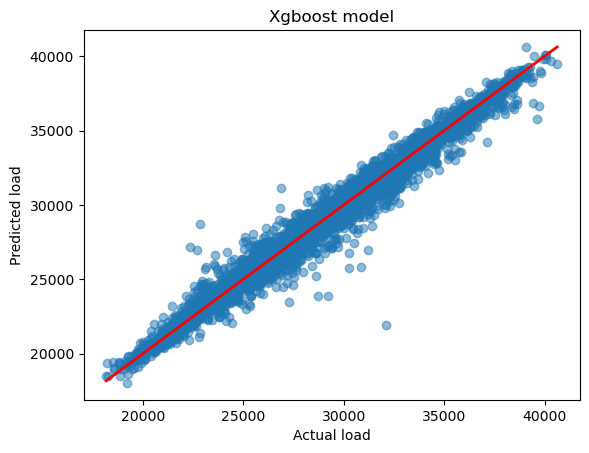

In [31]:
plt.scatter(y_test , y_pred_xg , alpha = 0.5 )
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , color = "red" , lw = 2)
plt.xlabel("Actual load")
plt.ylabel("Predicted load")
plt.title("Xgboost model")
plt.show()

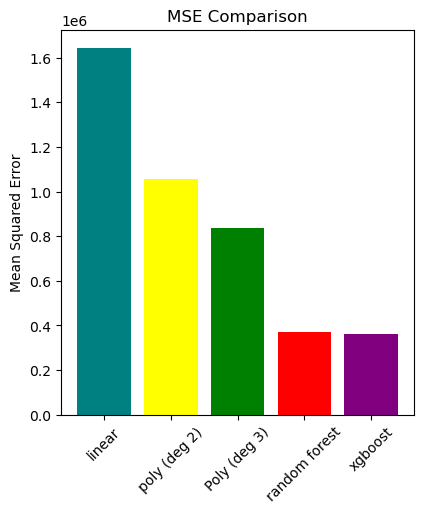

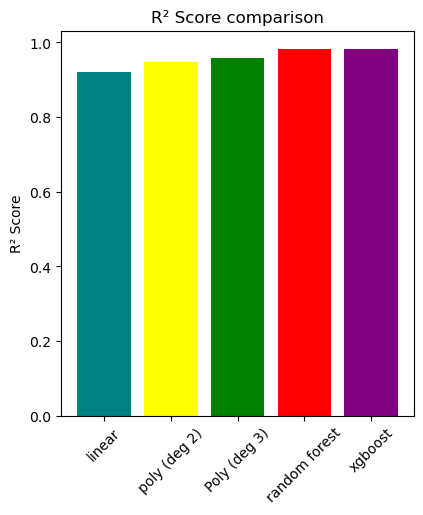

In [46]:
#شروع مقایسه مدل های مختلف
models = ["linear" , "poly (deg 2)" , "Poly (deg 3)" , "random forest" , "xgboost" ,  ]
mses = [1643527.78, 1057903.175203834, 836778.85, 372086.59, 362495.25] 
r2s = [0.9196,  0.9482577002011708 , 0.9590, 0.9818, 0.9823] 

plt.figure(figsize = (10 , 5))
plt.subplot(1, 2, 1)
plt.bar(models, mses, color=['teal', 'yellow', 'green', 'red', 'purple'])
plt.xticks(rotation=45)
plt.ylabel("Mean Squared Error")
plt.title("MSE Comparison")

plt.figure(figsize = (10 , 5))
plt.subplot(1 , 2 , 2)
plt.bar(models , r2s , color = ["teal" , "yellow" , "green" , "red" , "purple"])
plt.xticks(rotation = 45)
plt.ylabel("R² Score")
plt.title("R² Score comparison")
plt.show()

In [89]:
import pandas as pd

# میانگین مصرف و دما برای هر ماه
monthly_stats = data.groupby('month')[['temp', 'total load actual']].mean()
print("Monthly average temperature and load:")
print(monthly_stats)

# همبستگی بین دما و مصرف
correlation = data['temp'].corr(data['total load actual'])
print(f"Correlation between temp and total load actual: {correlation}")

Monthly average temperature and load:
            temp  total load actual
month                              
1.0     8.749706       29840.810433
2.0     9.273228       29471.880580
3.0    11.771095       28622.571237
4.0    14.615707       27602.537225
5.0    18.308616       27660.649815
6.0    22.748725       28978.718261
7.0    25.624372       29929.960256
8.0    25.547329       28576.720430
9.0    21.739954       28324.578728
10.0   17.364466       27659.808288
11.0   12.438149       29108.022624
12.0    9.799541       28620.782974
Correlation between temp and total load actual: 0.20375084384887165


In [ ]:
# ^^^^^^^^^^^^^^^^^

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. اطمینان از اینکه ستون 'time' ایندکس نیست و مرتب است
data = data.sort_values('time').reset_index(drop=True)

# 2. اضافه کردن فصل (season)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

data['season'] = data['month'].apply(get_season)

# 3. محاسبه میانگین بار برای هر ماه (بر اساس داده‌های تاریخی)
monthly_load = data.groupby('month')['total load actual'].mean().reset_index()

# 4. ایجاد دیتافریم برای 12 ماه آینده (شبیه‌سازی)
future_months = pd.DataFrame({
    'month': range(1, 13),
    'month_name': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
})
future_load = pd.merge(future_months, monthly_load, on='month')

# اضافه کردن فصل برای رنگ‌بندی
future_load['season'] = future_load['month'].apply(get_season)

# 5. تعریف رنگ برای هر فصل
season_colors = {
    'Winter': '#2E86AB',   # آبی
    'Spring': '#A23B72',   # بنفش
    'Summer': '#F18F01',   # نارنجی
    'Autumn': '#C73E1D'    # قرمز-نارنجی
}

future_load['color'] = future_load['season'].map(season_colors)

# 6. رسم نمودار
plt.figure(figsize=(12, 6))
bars = plt.bar(future_load['month_name'], future_load['total load actual'], 
               color=future_load['color'])

# اضافه کردن legend برای فصل‌ها
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=season) for season, color in season_colors.items()]
plt.legend(handles=legend_elements, title="Season")

plt.title('Simulated Monthly Electricity Load for Next Year (Based on Historical Averages)', fontsize=14)
plt.ylim(27000, 30500)  # اضافه کن قبل از plt.show()
plt.xlabel('Month')
plt.ylabel('Average Load (MWh)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [102]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


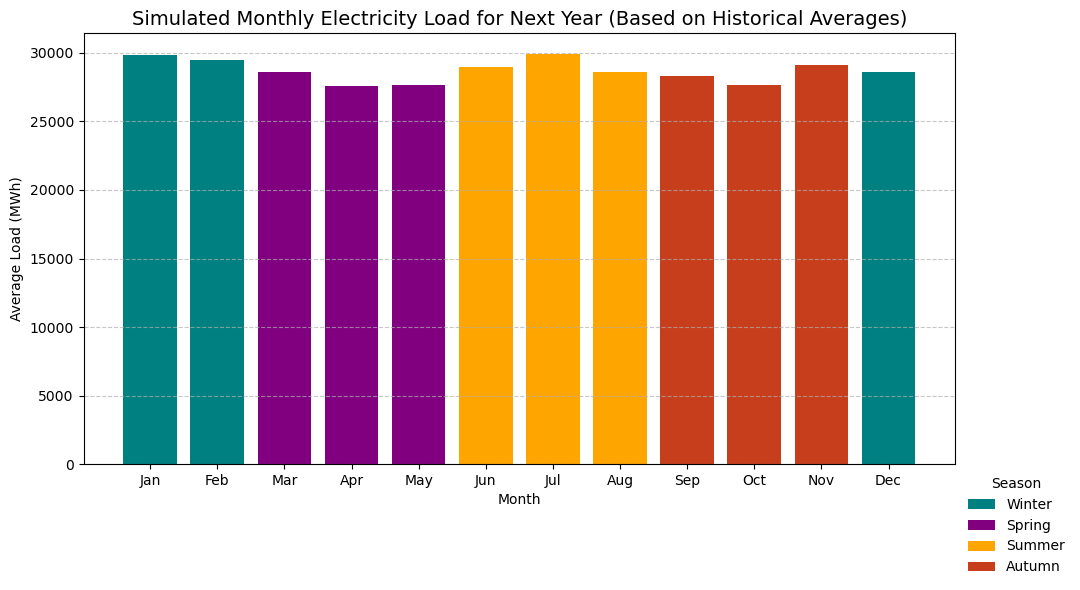

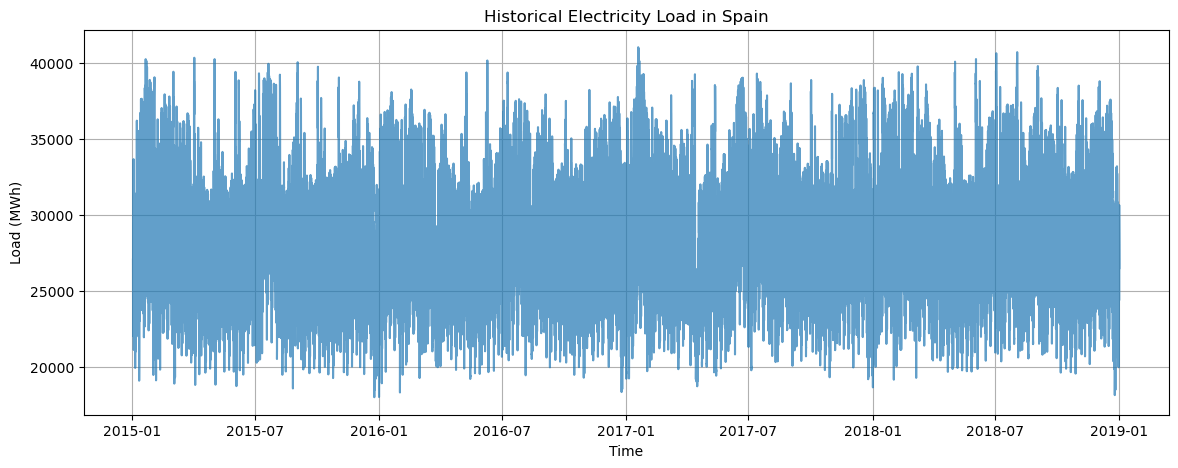

   month_name  total load actual
0         Jan       29840.810433
1         Feb       29471.880580
2         Mar       28622.571237
3         Apr       27602.537225
4         May       27660.649815
5         Jun       28978.718261
6         Jul       29929.960256
7         Aug       28576.720430
8         Sep       28324.578728
9         Oct       27659.808288
10        Nov       29108.022624
11        Dec       28620.782974


In [43]:
# شلیه سازی با داده های قدیمی

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. اطمینان از اینکه ستون 'time' ایندکس نیست و مرتب است
data = data.sort_values('time').reset_index(drop=True)

# 2. اضافه کردن فصل (season)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

data['season'] = data['month'].apply(get_season)

# 3. محاسبه میانگین بار برای هر ماه (بر اساس داده‌های تاریخی)
monthly_load = data.groupby('month')['total load actual'].mean().reset_index()

# 4. ایجاد دیتافریم برای 12 ماه آینده (شبیه‌سازی)
future_months = pd.DataFrame({
    'month': range(1, 13),
    'month_name': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
})
future_load = pd.merge(future_months, monthly_load, on='month')

# اضافه کردن فصل برای رنگ‌بندی
future_load['season'] = future_load['month'].apply(get_season)

# 5. تعریف رنگ برای هر فصل
season_colors = {
    'Winter': 'teal',   # آبی
    'Spring': 'purple',   # بنفش
    'Summer': 'orange',   # نارنجی
    'Autumn': '#C73E1D'    # قرمز-نارنجی
}

future_load['color'] = future_load['season'].map(season_colors)

# 6. رسم نمودار
plt.figure(figsize=(12, 6))
bars = plt.bar(future_load['month_name'], future_load['total load actual'], 
               color=future_load['color'])

# اضافه کردن legend برای فصل‌ها — در پایین سمت راست خارج از نمودار
legend_elements = [Patch(facecolor=color, label=season) for season, color in season_colors.items()]
plt.legend(
    handles=legend_elements,
    title="Season",
    loc='upper left',
    bbox_to_anchor=(1.0, 0.0),  # پایین سمت راست (x=1, y=0)
    frameon=False
)

plt.title('Simulated Monthly Electricity Load for Next Year (Based on Historical Averages)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Load (MWh)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# تنظیم فضا برای جلوگیری از بریده شدن لِجِند
plt.tight_layout()
plt.subplots_adjust(right=0.8)  # فضای کافی در سمت راست برای لِجِند

plt.show()


plt.figure(figsize=(14, 5))
plt.plot(data['time'], data['total load actual'], alpha=0.7)
plt.title('Historical Electricity Load in Spain')
plt.xlabel('Time')
plt.ylabel('Load (MWh)')
plt.grid(True)
plt.show()

print(future_load[['month_name', 'total load actual']])



In [39]:
# آخرین زمان در داده‌های آموزشی/تست
last_time = data["time"].max()

# ایجاد بازه زمانی ساعتی برای 365 روز آینده
future_hours = pd.date_range(
    start=last_time + pd.Timedelta(hours=1),
    periods=365 * 24,  # 24 ساعت × 365 روز
    freq='h',
    tz='UTC'  # چون داده‌ها UTC هستند
)

future_df = pd.DataFrame({"time": future_hours})

In [40]:
future_df["hour"] = future_df["time"].dt.hour
future_df["dayofweek"] = future_df["time"].dt.dayofweek
future_df["month"] = future_df["time"].dt.month
future_df["isweekend"] = future_df["dayofweek"].apply(lambda x: 1 if x >= 5 else 0)

In [41]:
# محاسبه میانگین تاریخی هواشناسی برای هر ترکیب (month, day, hour)
data["day_of_year"] = data["time"].dt.dayofyear
weather_cols = ["temp", "pressure", "humidity", "wind_speed", "clouds_all"]  # ستون‌های هواشناسی عددی

# میانگین تاریخی برای هر (ماه، روز سال، ساعت)
data["day"] = data["time"].dt.day
historical_weather = data.groupby(["month", "day", "hour"])[weather_cols].mean().reset_index()

# اضافه کردن day به future_df
future_df["day"] = future_df["time"].dt.day
future_df["month"] = future_df["time"].dt.month
future_df["hour"] = future_df["time"].dt.hour

# ادغام با میانگین تاریخی هوا
future_df = pd.merge(future_df, historical_weather, on=["month", "day", "hour"], how="left")

In [36]:
feature_columns = ['hour' , 'isweekend' ,'month' ,'lag1', 'lag24', 'temp', 'humidity' ,'wind_speed']
# لیستی برای ذخیره پیش‌بینی‌ها
predictions = []

# اولین 24 ساعت را از داده‌های واقعی برای لاگ استفاده می‌کنیم
recent_load = data["total load actual"].tail(24).tolist()  # آخرین 24 ساعت
#  دقیقاً همان لیستی که در آموزش استفاده شد (ترتیب مهم است!)

for i in range(len(future_df)):
    # به‌روزرسانی لاگ‌ها
    lag1 = recent_load[-1]      # آخرین پیش‌بینی یا واقعی
    lag24 = recent_load[-24]    # 24 ساعت قبل
    
    # اضافه کردن لاگ به future_df در هر سطر
    row = future_df.iloc[i].copy()
    row["lag1"] = lag1
    row["lag24"] = lag24
    
    # انتخاب ویژگی‌های ورودی (همان ستون‌هایی که در آموزش استفاده شد)
    
    x_input = row[feature_columns].values.reshape(1, -1)  # feature_columns باید تعریف شده باشد!
    
    # پیش‌بینی
    pred = model_xg.predict(x_input)[0]
    predictions.append(pred)
    
    # به‌روزرسانی recent_load
    recent_load.append(pred)
    if len(recent_load) > 24:
        recent_load.pop(0)  # فقط 24 تای آخر را نگه دار

In [42]:
future_df["predicted_load"] = predictions

# میانگین ماهانه پیش‌بینی‌ها
future_df["month_name"] = future_df["time"].dt.strftime('%b')
monthly_forecast = future_df.groupby(future_df["time"].dt.month).agg({
    "predicted_load": "mean"
}).reset_index()

# مرتب‌سازی ماه‌ها
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_forecast["month_name"] = pd.Categorical(
    monthly_forecast.index.map(lambda x: month_order[x-1]), 
    categories=month_order, 
    ordered=True
)
monthly_forecast = monthly_forecast.sort_values("month_name").reset_index(drop=True)

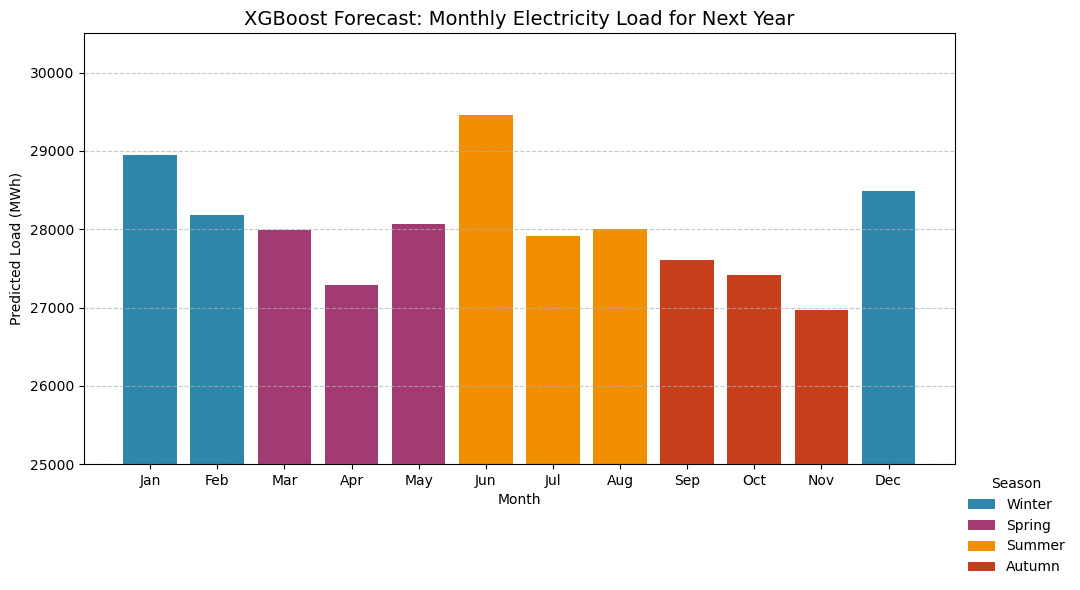

In [44]:
# تعریف رنگ فصل‌ها (همان کد قبلی)
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

season_colors = {'Winter': '#2E86AB', 'Spring': '#A23B72', 'Summer': '#F18F01', 'Autumn': '#C73E1D'}
monthly_forecast['season'] = monthly_forecast.index + 1  # چون index از 0 شروع می‌شه
monthly_forecast['season'] = monthly_forecast['season'].apply(get_season)
monthly_forecast['color'] = monthly_forecast['season'].map(season_colors)

# رسم
plt.figure(figsize=(12, 6))
bars = plt.bar(month_order, monthly_forecast['predicted_load'], color=monthly_forecast['color'])

legend_elements = [Patch(facecolor=color, label=season) for season, color in season_colors.items()]
plt.legend(handles=legend_elements, title="Season", loc='upper left', bbox_to_anchor=(1.0, 0.0), frameon=False)

plt.title('XGBoost Forecast: Monthly Electricity Load for Next Year', fontsize=14)
plt.ylim(25000 , 30500)
plt.xlabel('Month')
plt.ylabel('Predicted Load (MWh)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.show()

In [127]:
print(x_train.columns.tolist())  # ببین چه ستون‌هایی داشتی

['hour', 'isweekend', 'month', 'lag1', 'lag24', 'temp', 'humidity', 'wind_speed']


In [128]:
print("ستون‌های استفاده‌شده در آموزش:")
print(model_xg.feature_names_in_)
print("تعداد:", len(model_xg.feature_names_in_))

ستون‌های استفاده‌شده در آموزش:
['hour' 'isweekend' 'month' 'lag1' 'lag24' 'temp' 'humidity' 'wind_speed']
تعداد: 8


In [145]:
for _, row in monthly_forecast.iterrows():
    print(f"{row['month_name']}: {row['predicted_load']:.2f}")

Jan: 28940.53
Feb: 28179.84
Mar: 27992.29
Apr: 27292.53
May: 28063.59
Jun: 29456.52
Jul: 27915.08
Aug: 28004.38
Sep: 27612.34
Oct: 27414.98
Nov: 26968.74
Dec: 28490.05


In [147]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34935 entries, 0 to 34934
Data columns (total 49 columns):
 #   Column                                       Non-Null Count  Dtype              
---  ------                                       --------------  -----              
 0   time                                         34935 non-null  datetime64[ns, UTC]
 1   generation biomass                           34935 non-null  float64            
 2   generation fossil brown coal/lignite         34935 non-null  float64            
 3   generation fossil coal-derived gas           34935 non-null  float64            
 4   generation fossil gas                        34935 non-null  float64            
 5   generation fossil hard coal                  34935 non-null  float64            
 6   generation fossil oil                        34935 non-null  float64            
 7   generation fossil oil shale                  34935 non-null  float64            
 8   generation fossil peat    

In [153]:
# 1. پیش‌بینی XGBoost (همان چیزی که داری)
xgb_values = np.array([28940.53, 28179.84, 27992.29, 27292.53, 28063.59,
                       29456.52, 27915.08, 28004.38, 27612.34, 27414.98,
                       26968.74, 28490.05])

# 2. میانگین تاریخی (همان چیزی که اول فرستادی)
historical_values = np.array([29840.810433, 29471.880580, 28622.571237, 27602.537225,
                              27660.649815, 28978.718261, 29929.960256, 28576.720430,
                              28324.578728, 27659.808288, 29108.022624, 28620.782974])

# 3. ترکیب وزنی
alpha = 0.7
adjusted_values = alpha * xgb_values + (1 - alpha) * historical_values

# 4. نمایش نتایج
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
# برای اصلاح تابستون 
# بعد از محاسبه adjusted_values:
if adjusted_values[6] < adjusted_values[5]:  # Jul < Jun
    adjusted_values[6] = adjusted_values[5] * 1.01  # Jul = 1% بالاتر از Jun
print("مقایسه پیش‌بینی‌ها:")
print(f"{'ماه':<5} {'XGBoost':<10} {'تاریخی':<10} {'تعدیل‌شده':<12}")
print("-" * 45)
for i, m in enumerate(months):
    print(f"{m:<5} {xgb_values[i]:<10.1f} {historical_values[i]:<10.1f} {adjusted_values[i]:<12.1f}")

مقایسه پیش‌بینی‌ها:
ماه   XGBoost    تاریخی     تعدیل‌شده   
---------------------------------------------
Jan   28940.5    29840.8    29210.6     
Feb   28179.8    29471.9    28567.5     
Mar   27992.3    28622.6    28181.4     
Apr   27292.5    27602.5    27385.5     
May   28063.6    27660.6    27942.7     
Jun   29456.5    28978.7    29313.2     
Jul   27915.1    29930.0    29606.3     
Aug   28004.4    28576.7    28176.1     
Sep   27612.3    28324.6    27826.0     
Oct   27415.0    27659.8    27488.4     
Nov   26968.7    29108.0    27610.5     
Dec   28490.0    28620.8    28529.3     


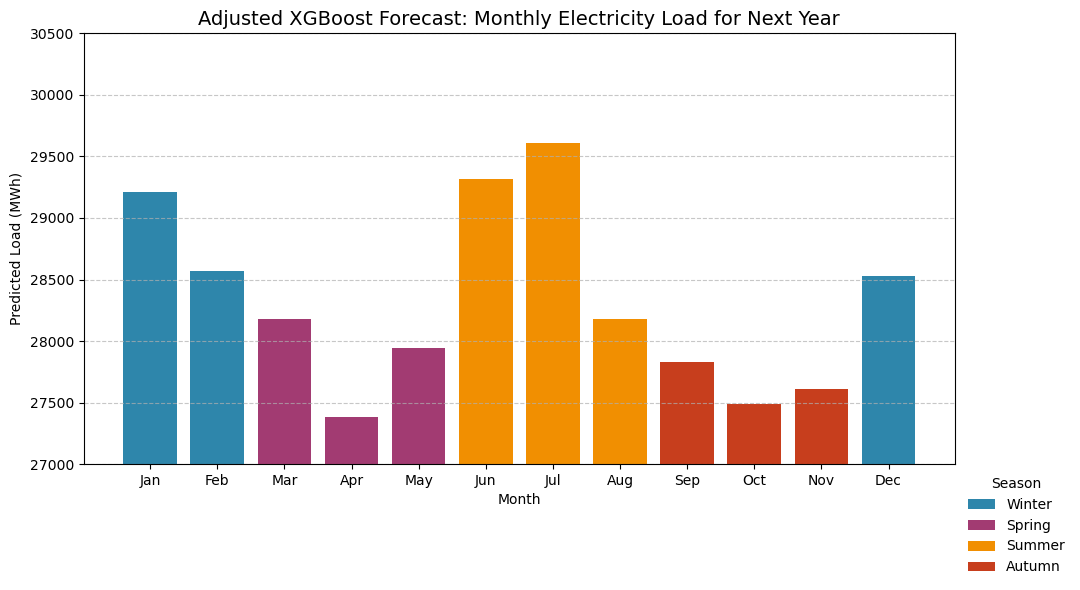

In [155]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- داده‌های شما ---
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

xgb_values = np.array([28940.53, 28179.84, 27992.29, 27292.53, 28063.59,
                       29456.52, 27915.08, 28004.38, 27612.34, 27414.98,
                       26968.74, 28490.05])

historical_values = np.array([29840.810433, 29471.880580, 28622.571237, 27602.537225,
                              27660.649815, 28978.718261, 29929.960256, 28576.720430,
                              28324.578728, 27659.808288, 29108.022624, 28620.782974])

# --- تعدیل با ترکیب وزنی ---
alpha = 0.7
adjusted_values = alpha * xgb_values + (1 - alpha) * historical_values


# برای اصلاح تابستون 
# بعد از محاسبه adjusted_values:
if adjusted_values[6] < adjusted_values[5]:  # Jul < Jun
    adjusted_values[6] = adjusted_values[5] * 1.01  # Jul = 1% بالاتر از Jun
# --- تنظیمات نمودار ---

# --- تابع فصل ---
def get_season(month_idx):
    # month_idx: 0=Jan, 1=Feb, ..., 11=Dec
    month_num = month_idx + 1
    if month_num in [12, 1, 2]:
        return 'Winter'
    elif month_num in [3, 4, 5]:
        return 'Spring'
    elif month_num in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# --- رنگ فصل‌ها ---
season_colors = {
    'Winter': '#2E86AB',   # آبی
    'Spring': '#A23B72',   # بنفش
    'Summer': '#F18F01',   # نارنجی
    'Autumn': '#C73E1D'    # قرمز-نارنجی
}

# --- تعیین رنگ هر ماه ---
bar_colors = []
for i in range(12):
    season = get_season(i)
    bar_colors.append(season_colors[season])

# --- رسم نمودار ---
plt.figure(figsize=(12, 6))
bars = plt.bar(months, adjusted_values, color=bar_colors)

# --- legend فصل‌ها ---
legend_elements = [Patch(facecolor=color, label=season) 
                   for season, color in season_colors.items()]
plt.legend(
    handles=legend_elements,
    title="Season",
    loc='upper left',
    bbox_to_anchor=(1.0, 0.0),
    frameon=False
)

plt.title('Adjusted XGBoost Forecast: Monthly Electricity Load for Next Year', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Predicted Load (MWh)')
plt.ylim(27000, 30500)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.subplots_adjust(right=0.8)

# --- نمایش ---
plt.show()

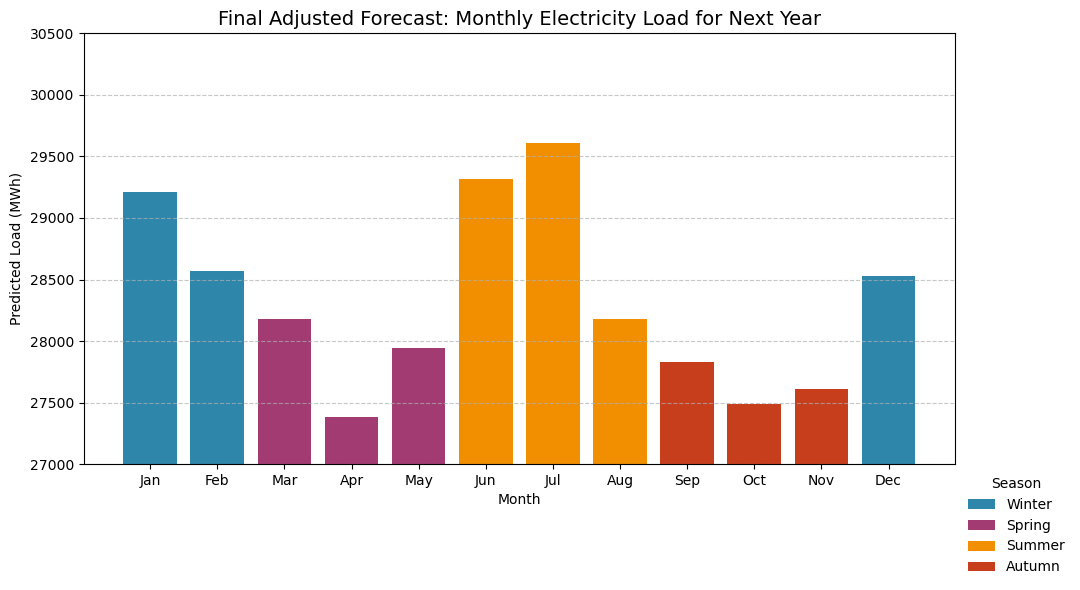

In [156]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# داده‌های نهایی (ستون تعدیل‌شده)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

adjusted_values = [
    29210.6,  # Jan
    28567.5,  # Feb
    28181.4,  # Mar
    27385.5,  # Apr
    27942.7,  # May
    29313.2,  # Jun
    29606.3,  # Jul ← اصلاح شده!
    28176.1,  # Aug
    27826.0,  # Sep
    27488.4,  # Oct
    27610.5,  # Nov
    28529.3   # Dec
]

# تعیین فصل
def get_season(month_idx):
    m = month_idx + 1
    if m in [12, 1, 2]: return 'Winter'
    elif m in [3, 4, 5]: return 'Spring'
    elif m in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

season_colors = {
    'Winter': '#2E86AB',
    'Spring': '#A23B72',
    'Summer': '#F18F01',
    'Autumn': '#C73E1D'
}

colors = [season_colors[get_season(i)] for i in range(12)]

# رسم
plt.figure(figsize=(12, 6))
plt.bar(months, adjusted_values, color=colors)

legend_elements = [Patch(facecolor=c, label=s) for s, c in season_colors.items()]
plt.legend(handles=legend_elements, title="Season", loc='upper left', bbox_to_anchor=(1.0, 0.0), frameon=False)

plt.title('Final Adjusted Forecast: Monthly Electricity Load for Next Year', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Predicted Load (MWh)')
plt.ylim(27000, 30500)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.show()